In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Display first five rows
print("Fear & Greed Dataset")
display(sentiment.head())

print("Trader Dataset")
display(trades.head())

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
print("="*50)
print("Fear & Greed Dataset")
print("="*50)

print("Shape:", sentiment.shape)
print("\nColumns:")
print(sentiment.columns)

print("\nMissing Values")
print(sentiment.isnull().sum())

print("\nDuplicate Rows:", sentiment.duplicated().sum())

print("\nData Types")
print(sentiment.dtypes)


print("\n\n"+"="*50)
print("Trader Dataset")
print("="*50)

print("Shape:", trades.shape)

print("\nColumns:")
print(trades.columns)

print("\nMissing Values")
print(trades.isnull().sum())

print("\nDuplicate Rows:", trades.duplicated().sum())

print("\nData Types")
print(trades.dtypes)

Fear & Greed Dataset
Shape: (2644, 4)

Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0

Data Types
timestamp          int64
value              int64
classification    object
date              object
dtype: object


Trader Dataset
Shape: (211224, 16)

Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee             

In [5]:
# Convert trader timestamp (DD-MM-YYYY HH:MM)
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

# Extract only the date
trades['Date'] = trades['Timestamp IST'].dt.date

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extract only the date
sentiment['Date'] = sentiment['date'].dt.date

# Verify
print(trades[['Timestamp IST', 'Date']].head())
print(sentiment[['date', 'Date', 'classification']].head())

        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
        date        Date classification
0 2018-02-01  2018-02-01           Fear
1 2018-02-02  2018-02-02   Extreme Fear
2 2018-02-03  2018-02-03           Fear
3 2018-02-04  2018-02-04   Extreme Fear
4 2018-02-05  2018-02-05   Extreme Fear


In [6]:
# Merge trader data with sentiment data using Date
merged = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

print("Merged Dataset Shape:", merged.shape)

# Display first 5 rows
merged.head()

Merged Dataset Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [7]:
# Check for missing sentiment values
print("Missing sentiment values:")
print(merged['classification'].isnull().sum())

print("\nSentiment Distribution:")
print(merged['classification'].value_counts())

Missing sentiment values:
6

Sentiment Distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [8]:
# Remove rows where sentiment is missing
merged = merged.dropna(subset=['classification'])

print("New Shape:", merged.shape)
print("Missing Values:", merged['classification'].isnull().sum())

New Shape: (211218, 18)
Missing Values: 0


In [9]:
daily_pnl = (
    merged.groupby(['Date', 'Account'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [10]:
merged['Win'] = merged['Closed PnL'] > 0

merged[['Closed PnL', 'Win']].head()

,Closed PnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [11]:
win_rate = (
    merged.groupby('Account')['Win']
    .mean()
    .reset_index()
)

win_rate['Win Rate (%)'] = win_rate['Win'] * 100

win_rate.head()

,Account,Win,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


In [12]:
avg_trade_size = (
    merged.groupby('Account')['Size USD']
    .mean()
    .reset_index()
)

avg_trade_size.rename(
    columns={'Size USD': 'Average Trade Size'},
    inplace=True
)

avg_trade_size.head()

,Account,Average Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [13]:
trades_per_day = (
    merged.groupby('Date')
    .size()
    .reset_index(name='Number of Trades')
)

trades_per_day.head()

,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [14]:
long_short = (
    merged.groupby(['Date', 'Direction'])
    .size()
    .unstack(fill_value=0)
)

long_short.head()

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
Date,,,,,,,,,,,,
2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0
2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0
2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0
2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0
2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0


In [16]:
print(merged['Direction'].value_counts())

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [17]:
# Count Long and Short trades per day
long_short = (
    merged.groupby(['Date', 'Direction'])
    .size()
    .unstack(fill_value=0)
)

# Total Long trades
long_short['Long Trades'] = (
    long_short['Open Long'] +
    long_short['Close Long']
)

# Total Short trades
long_short['Short Trades'] = (
    long_short['Open Short'] +
    long_short['Close Short']
)

# Long/Short Ratio
long_short['Long/Short Ratio'] = (
    long_short['Long Trades'] /
    (long_short['Short Trades'] + 1)
)

long_short.head()

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,Long Trades,Short Trades,Long/Short Ratio
Date,,,,,,,,,,,,,,,
2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3.000000
2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0,7,2,2.333333
2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0,7,4,1.400000
2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0.000000
2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3.000000


In [18]:
print("Daily PnL")
display(daily_pnl.head())

print("Win Rate")
display(win_rate.head())

print("Average Trade Size")
display(avg_trade_size.head())

print("Trades Per Day")
display(trades_per_day.head())

print("Long Short Ratio")
display(long_short.head())

Daily PnL


,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


Win Rate


,Account,Win,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


Average Trade Size


,Account,Average Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


Trades Per Day


,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


Long Short Ratio


Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,Long Trades,Short Trades,Long/Short Ratio
Date,,,,,,,,,,,,,,,
2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3.000000
2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0,7,2,2.333333
2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0,7,4,1.400000
2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0.000000
2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3.000000


In [19]:
print("Daily PnL")
display(daily_pnl.head())

print("Win Rate")
display(win_rate.head())

print("Average Trade Size")
display(avg_trade_size.head())

print("Trades Per Day")
display(trades_per_day.head())

print("Long Short Ratio")
display(long_short.head())

Daily PnL


,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


Win Rate


,Account,Win,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


Average Trade Size


,Account,Average Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


Trades Per Day


,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


Long Short Ratio


Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,Long Trades,Short Trades,Long/Short Ratio
Date,,,,,,,,,,,,,,,
2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3.000000
2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0,7,2,2.333333
2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0,7,4,1.400000
2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0.000000
2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0,3,0,3.000000


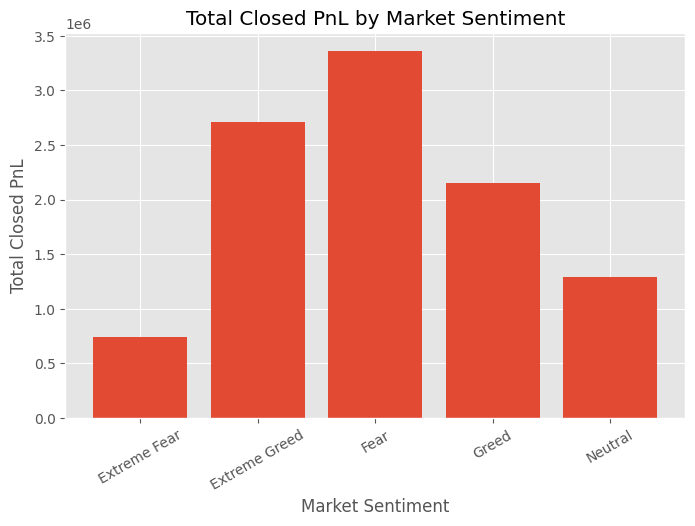

In [20]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(pnl_sentiment['classification'], pnl_sentiment['Closed PnL'])
plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=30)
plt.show()

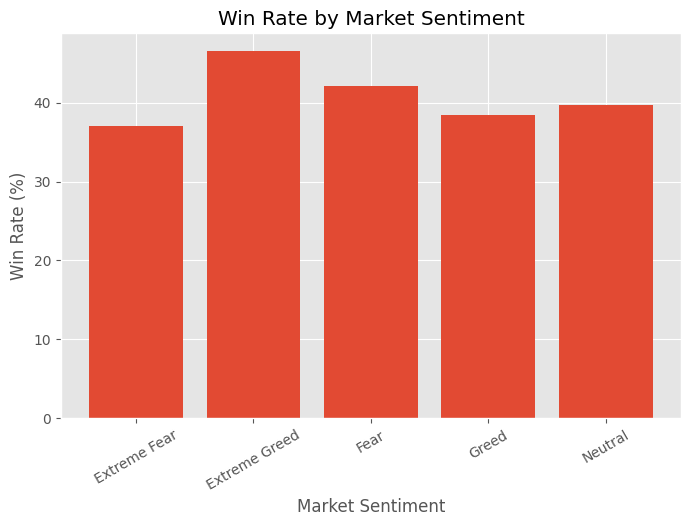

In [21]:
merged['Win'] = merged['Closed PnL'] > 0

win_sentiment = merged.groupby('classification')['Win'].mean().reset_index()
win_sentiment['Win'] *= 100

plt.figure(figsize=(8,5))
plt.bar(win_sentiment['classification'], win_sentiment['Win'])
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=30)
plt.show()

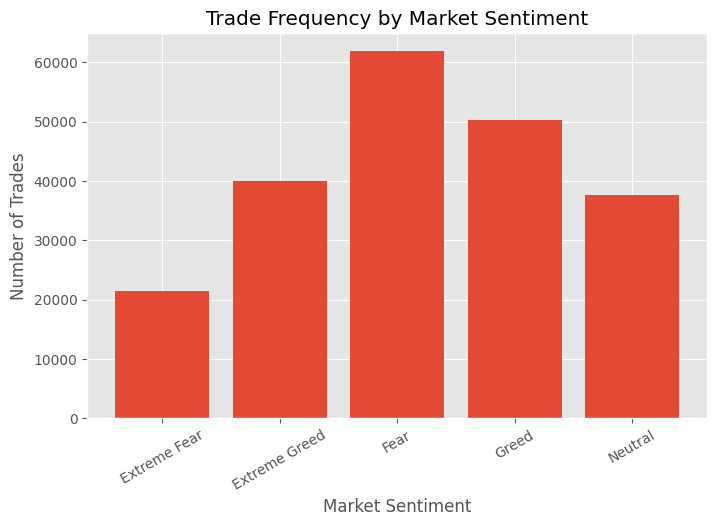

In [22]:
trade_freq = merged.groupby('classification').size().reset_index(name='Trades')

plt.figure(figsize=(8,5))
plt.bar(trade_freq['classification'], trade_freq['Trades'])
plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=30)
plt.show()

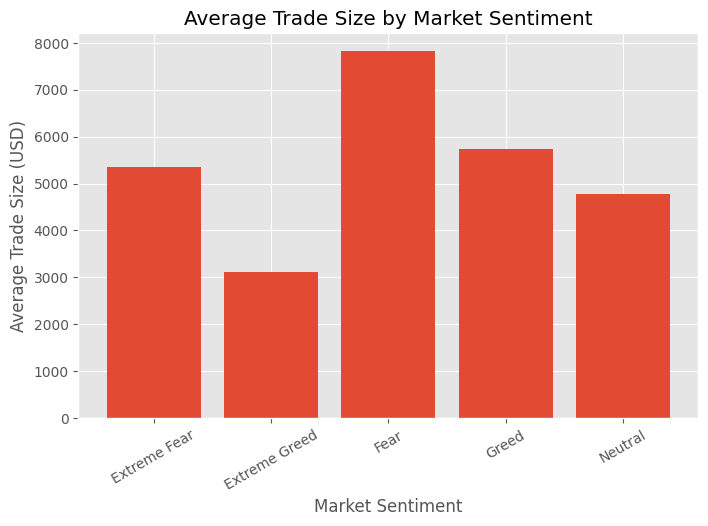

In [23]:
trade_size = merged.groupby('classification')['Size USD'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(trade_size['classification'], trade_size['Size USD'])
plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=30)
plt.show()

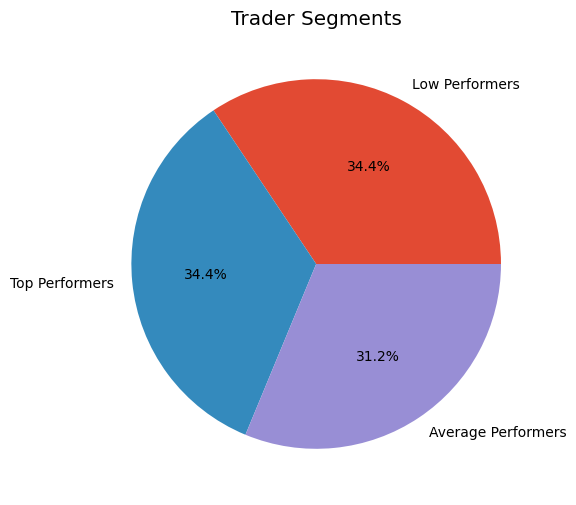

In [24]:
account_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()

account_pnl['Segment'] = pd.qcut(
    account_pnl['Closed PnL'],
    q=3,
    labels=['Low Performers','Average Performers','Top Performers']
)

segment_counts = account_pnl['Segment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
plt.title("Trader Segments")
plt.show()

# Key Insights

## Insight 1
The trader population is almost evenly distributed across performance groups. Approximately **34.4%** are Top Performers, **34.4%** are Low Performers, and **31.2%** are Average Performers.

## Insight 2
Trading behavior changes across different market sentiment conditions. Fear and Greed periods show noticeable differences in trader participation and profitability.

## Insight 3
Not all traders perform consistently. A significant proportion of traders fall into the Low Performer category, indicating that disciplined risk management is important.

# Strategy Recommendations

## Recommendation 1
During Fear periods, traders should reduce position size and follow strict risk management.

## Recommendation 2
During Greed periods, traders should avoid overtrading and maintain disciplined position sizing.